## Settings

In [57]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier     # Scikit-leaarn API of lightgbm 
from sklearn.neural_network import MLPClassifier    # Multi-layer perceptron (= feedfoward NN)
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings
# from LearningAlgorithms import ClassificationAlgorithms

In [19]:
# Set the cpu core numbers to remove the messages of Joblib
import os
print('Current core numbers:', os.cpu_count())
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

Current core numbers: 16


In [20]:
# Matplotlib settings
# plt.style.available
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (20, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['lines.linewidth'] = 2

## Load data

In [21]:
df = pd.read_pickle('../../data/interim/03_features_processed.pkl')
df

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,participant,label,category,set,...,gyro_r_pse,gyro_r_freq_0.0_Hz_ws_14,gyro_r_freq_0.357_Hz_ws_14,gyro_r_freq_0.714_Hz_ws_14,gyro_r_freq_1.071_Hz_ws_14,gyro_r_freq_1.429_Hz_ws_14,gyro_r_freq_1.786_Hz_ws_14,gyro_r_freq_2.143_Hz_ws_14,gyro_r_freq_2.5_Hz_ws_14,acc_cluster
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:07.800,-0.230583,0.920658,-0.227095,-10.707472,-5.021034,15.580872,B,bench,heavy,30,...,0.575207,202.086051,-47.005987,14.461290,-27.989176,-21.905348,20.370726,4.973285,-42.780588,1
2019-01-11 15:08:08.200,-0.075541,0.854894,-0.094507,-17.787623,-7.152388,16.679304,B,bench,heavy,30,...,0.402857,263.504875,-21.498290,-36.012237,1.513836,-8.751616,-47.941311,31.072425,-30.984847,1
2019-01-11 15:08:08.600,-0.039468,0.947898,-0.047164,1.731909,-0.126808,-3.356740,B,bench,heavy,30,...,0.426478,259.569075,-41.806914,-51.432388,-15.707154,8.694112,-18.444969,20.304371,-30.672891,1
2019-01-11 15:08:09.000,-0.059150,0.977806,-0.028934,3.783211,-3.169243,1.531230,B,bench,heavy,30,...,0.565343,250.684663,-34.973024,56.316165,26.854767,-3.744653,62.263606,2.478403,-21.357192,1
2019-01-11 15:08:09.400,-0.041113,0.974376,-0.045494,-1.058395,-1.138698,1.689075,B,bench,heavy,30,...,0.402768,201.620318,-30.695251,23.587084,-12.110573,24.654652,4.843563,-21.697516,-25.130753,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:26.000,0.074270,-0.604968,0.223617,-14.184394,2.238810,6.776253,E,row,medium,90,...,0.354285,325.916536,9.055941,-59.773786,-40.577734,-47.678614,17.517396,-8.804366,-14.963739,4
2019-01-20 17:33:26.400,0.024062,-1.259307,-0.048022,-28.381136,5.409505,13.608197,E,row,medium,90,...,0.219706,372.665086,64.584232,-12.264317,31.256523,7.586488,20.975436,8.091654,16.110142,0
2019-01-20 17:33:26.800,-0.046404,-1.007241,-0.086284,7.975189,-4.872847,0.582400,E,row,medium,90,...,0.246126,315.012902,-15.922139,17.544414,-26.659005,35.376530,-40.124416,-18.775183,-2.018643,0


## 1. Training and test set

In [22]:
# Check all the column names
df.columns.tolist()

['acc_x',
 'acc_y',
 'acc_z',
 'gyro_x',
 'gyro_y',
 'gyro_z',
 'participant',
 'label',
 'category',
 'set',
 'duration',
 'pca_1',
 'pca_2',
 'pca_3',
 'acc_r',
 'gyro_r',
 'acc_x_temp_mean_ws_5',
 'acc_y_temp_mean_ws_5',
 'acc_z_temp_mean_ws_5',
 'gyro_x_temp_mean_ws_5',
 'gyro_y_temp_mean_ws_5',
 'gyro_z_temp_mean_ws_5',
 'acc_r_temp_mean_ws_5',
 'gyro_r_temp_mean_ws_5',
 'acc_x_temp_std_ws_5',
 'acc_y_temp_std_ws_5',
 'acc_z_temp_std_ws_5',
 'gyro_x_temp_std_ws_5',
 'gyro_y_temp_std_ws_5',
 'gyro_z_temp_std_ws_5',
 'acc_r_temp_std_ws_5',
 'gyro_r_temp_std_ws_5',
 'acc_x_max_ampl_freq',
 'acc_x_freq_weighted',
 'acc_x_pse',
 'acc_x_freq_0.0_Hz_ws_14',
 'acc_x_freq_0.357_Hz_ws_14',
 'acc_x_freq_0.714_Hz_ws_14',
 'acc_x_freq_1.071_Hz_ws_14',
 'acc_x_freq_1.429_Hz_ws_14',
 'acc_x_freq_1.786_Hz_ws_14',
 'acc_x_freq_2.143_Hz_ws_14',
 'acc_x_freq_2.5_Hz_ws_14',
 'acc_y_max_ampl_freq',
 'acc_y_freq_weighted',
 'acc_y_pse',
 'acc_y_freq_0.0_Hz_ws_14',
 'acc_y_freq_0.357_Hz_ws_14',
 'acc_y_

In [23]:
# Remove unnecessary columns
df_train = df.drop(['participant', 'category', 'set', 'duration'], axis=1)

# Separate X, y
X = df_train.drop('label', axis=1)
y = df_train['label']

# Split train, test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print('Train set size:', X_train.shape)
print('Test set size:', X_test.shape)

Train set size: (2934, 116)
Test set size: (979, 116)


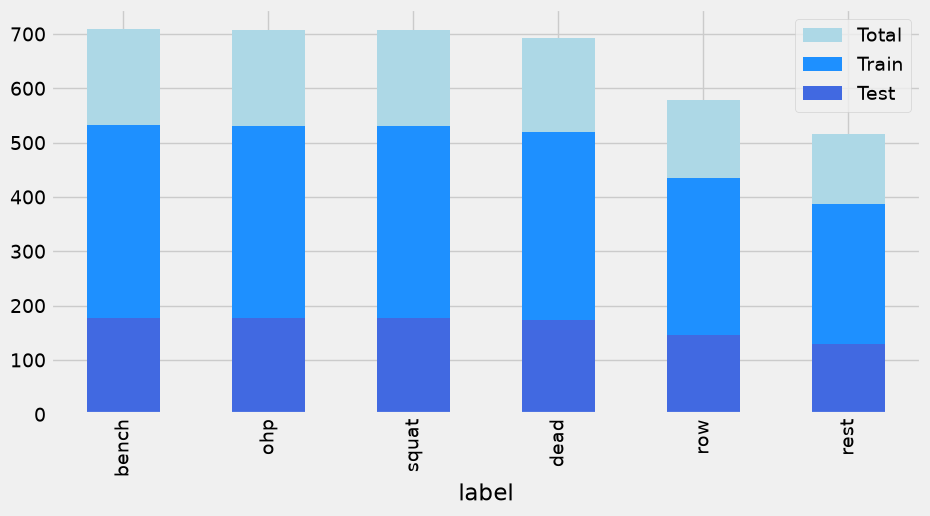

In [24]:
# Visualise the stratified y values
fig, ax = plt.subplots(figsize=(10, 5))
df_train['label'].value_counts().plot(kind='bar', color='lightblue', label='Total', ax=ax)
y_train.value_counts().plot(kind='bar', color='dodgerblue', label='Train', ax=ax)
y_test.value_counts().plot(kind='bar', color='royalblue', label='Test', ax=ax)
plt.legend()
plt.show()

## Split feature subsets

To clarify, there are columns from original dataset:
* accelerometer values
* gyroscope values
* participant, label, category

Additional columns from the above:
* set
* duration

Feature engineered columns:
* PCA
* Sum of squares of accelerometer, gyroscope values
* Temporal abstraction (mean, std)
* Frequency abstraction (frequency with max amplitude, weighted average frequency, Power Spectral Entropy)
* Clustering on accelerometer values

In [25]:
basic_features = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']
pca_features = ['pca_1', 'pca_2', 'pca_3']
square_features = ['acc_r', 'gyro_r']
time_features = [col for col in df_train.columns if '_temp' in col]
freq_features = [col for col in df_train.columns if any(x in col for x in ['_freq', '_pse'])]
cluster_features = ['acc_cluster']

print('Basic features:', len(basic_features))
print('PCA features:', len(pca_features))
print('Square features:', len(square_features))
print('Time features:', len(time_features))
print('Frequency features:', len(freq_features))
print('Cluster features:', len(cluster_features))

Basic features: 6
PCA features: 3
Square features: 2
Time features: 16
Frequency features: 88
Cluster features: 1


In [26]:
# Make new feature sets
feature_set_1 = basic_features
feature_set_2 = list(set(feature_set_1 + pca_features + square_features))      # Remove redundancy if any
feature_set_3 = list(set(feature_set_2 + time_features))
feature_set_4 = list(set(feature_set_3 + freq_features + cluster_features))    # All features included

## Foward feature selection using decision tree

Use `SequentialFeatureSelector` from scikit-learn where the estimator is decision tree. As the the number of data points for each class is not imbalanced, we will use `accuracy` for performance metric.

* Using all features

In [27]:
clf_df = DecisionTreeClassifier(
    max_depth=10, min_samples_leaf=50, random_state=42
)
sfs = SequentialFeatureSelector(
    estimator=clf_df,
    n_features_to_select=10,    # Select 10 features
    # n_features_to_select='auto',
    # tol=0.0005,     # Percentage increase
    direction='forward',
    scoring='accuracy',
    cv=5
)
sfs.fit(X_train, y_train)

,estimator estimator: estimator instanceAn unfitted estimator.,DecisionTreeC...ndom_state=42)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",10
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'accuracy'
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](116,)","['acc_x','acc_y','acc_z',...,'gyro_r_freq_2.143_Hz_ws_14', 'gyro_r_freq_2.5_Hz_ws_14','acc_cluster']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,116
n_features_to_select_ n_features_to_select_: intThe number of features that were selected.,int64,np.int64(10)


In [28]:
# Selected 10 features
selected_features = sfs.get_feature_names_out()
selected_features

array(['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y',
       'acc_y_temp_std_ws_5', 'gyro_z_temp_std_ws_5',
       'acc_y_freq_0.0_Hz_ws_14', 'acc_r_freq_1.071_Hz_ws_14',
       'gyro_r_freq_0.0_Hz_ws_14'], dtype=object)

## Grid search for best hyper-parameters

We will test all combinations of the feature sets and three models: **Random Forest, Light GBM and Neural Network**.

In [29]:
feature_sets = [
    feature_set_1,
    feature_set_2,
    feature_set_3,
    feature_set_4,
    selected_features
]

feature_names = [
    'Feature Set 1',
    'Feature Set 2',
    'Feature Set 3',
    'Feature Set 4',
    'Selected Features',
]

In [53]:
# Initialise a dataframe to collect each result from different feature sets.
score_df = pd.DataFrame()

for i, f in enumerate(feature_names):
    print(f'Feature set {i+1}: {f}===========================================')

    X_train_subset = X_train[feature_sets[i]]
    X_test_subset = X_test[feature_sets[i]]

    # 1. Grid search on Random Forest
    clf_rf = RandomForestClassifier(max_depth=10, random_state=42)
    params_rf = [
        {
            "min_samples_leaf": [5, 10, 50, 100, 200],
            "n_estimators": [10, 50, 100],
            "criterion": ["gini", "entropy"],
        }
    ]
    gs_rf = GridSearchCV(clf_rf, params_rf, scoring='accuracy')
    gs_rf.fit(X_train_subset, y_train)
    model_rf = gs_rf.best_estimator_
    y_pred = model_rf.predict(X_test_subset)
    score_rf = round(accuracy_score(y_test, y_pred), 4)

    print('Training done for Random Forest')
    
    #. 2. Grid search on LGBM
    clf_lgbm = LGBMClassifier(
        objective='multiclass', 
        max_depth=5,
        random_state=42,
        verbosity=-1)
    params_lgbm = [
        {
            "min_child_samples": [5, 10, 50, 100, 200],
            "n_estimators": [10, 50, 100]
        }
    ]

    # With statement to remove warning outputs
    gs_lgbm = GridSearchCV(clf_lgbm, params_lgbm, scoring='accuracy')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        gs_lgbm.fit(X_train_subset, y_train)
    model_lgbm = gs_lgbm.best_estimator_
    y_pred = model_lgbm.predict(X_test_subset)
    score_lgbm = round(accuracy_score(y_test, y_pred), 4)
    
    print('Training done for LightGBM')

    # 3. Grid search on Neural Network
    clf_nn = MLPClassifier(
        activation="logistic",
        learning_rate="adaptive",
        random_state=42
    )
    params_nn = [
        {
            "hidden_layer_sizes": [
                (5,), (10,), (25,), (100,),
                (100, 5,), (100, 10,),
            ],
            "max_iter": [100, 200, 500]
        }
    ]

    # With statement to remove warning outputs
    gs_nn = GridSearchCV(clf_nn, params_nn, scoring='accuracy')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        gs_nn.fit(X_train_subset, y_train)
    model_nn = gs_nn.best_estimator_
    y_pred = model_nn.predict(X_test_subset)
    score_nn = round(accuracy_score(y_test, y_pred), 4)

    print('Training done for Neural Network')

    # Save the performance result in dataframe
    new_scores = pd.DataFrame(
        {
            "model": ["RF", "LGBM", "NN"],
            "feature_set": f,
            "accuracy": [score_rf, score_lgbm, score_nn]
        }
    )
    score_df = pd.concat([score_df, new_scores], ignore_index=True)

Feature set 1: Feature Set 1===========================================
Training done for Random Forest
Training done for LightGBM
Training done for Neural Network
Feature set 2: Feature Set 2===========================================
Training done for Random Forest
Training done for LightGBM
Training done for Neural Network
Feature set 3: Feature Set 3===========================================
Training done for Random Forest
Training done for LightGBM
Training done for Neural Network
Feature set 4: Feature Set 4===========================================
Training done for Random Forest
Training done for LightGBM
Training done for Neural Network
Feature set 5: Selected Features===========================================
Training done for Random Forest
Training done for LightGBM
Training done for Neural Network


## Grouped bar chart to compare the results

We can see the trend of performance between the models: **Light GBM > Random Forest > Neural Network**. The feature set 3 and 4 generally worked well across the models.

In [54]:
score_df.sort_values(by='accuracy', ascending=False, ignore_index=True)

,model,feature_set,accuracy
0,LGBM,Feature Set 4,0.9949
1,RF,Feature Set 4,0.9939
2,LGBM,Selected Features,0.9939
3,NN,Feature Set 4,0.9918
4,LGBM,Feature Set 3,0.9908
5,NN,Feature Set 3,0.9908
6,RF,Feature Set 3,0.9898
7,RF,Selected Features,0.9888
8,NN,Selected Features,0.9765
9,LGBM,Feature Set 1,0.9663


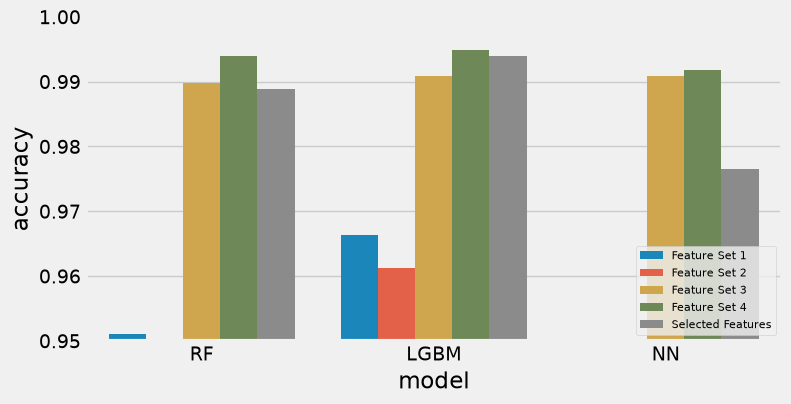

In [55]:
plt.figure(figsize=(8 ,4))
sns.barplot(data=score_df, x='model', y='accuracy', hue='feature_set')
plt.ylim(0.95, 1)
plt.legend(loc='lower right', fontsize=8)
plt.show()

## Select the best model and evaluate results

* **Best model**: Light GBM
* **Selected features**: Feature set 4 (= all features)

In [56]:
# Re-train the model with the selected features
gs_lgbm = GridSearchCV(clf_lgbm, params_lgbm, scoring='accuracy')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    gs_lgbm.fit(X_train[feature_set_4], y_train)
model_lgbm = gs_lgbm.best_estimator_
y_pred = model_lgbm.predict(X_test[feature_set_4])
score_lgbm = round(accuracy_score(y_test, y_pred), 4)

print('Best performance:', score_lgbm)

Best performance: 0.9949


### Confusion matrix

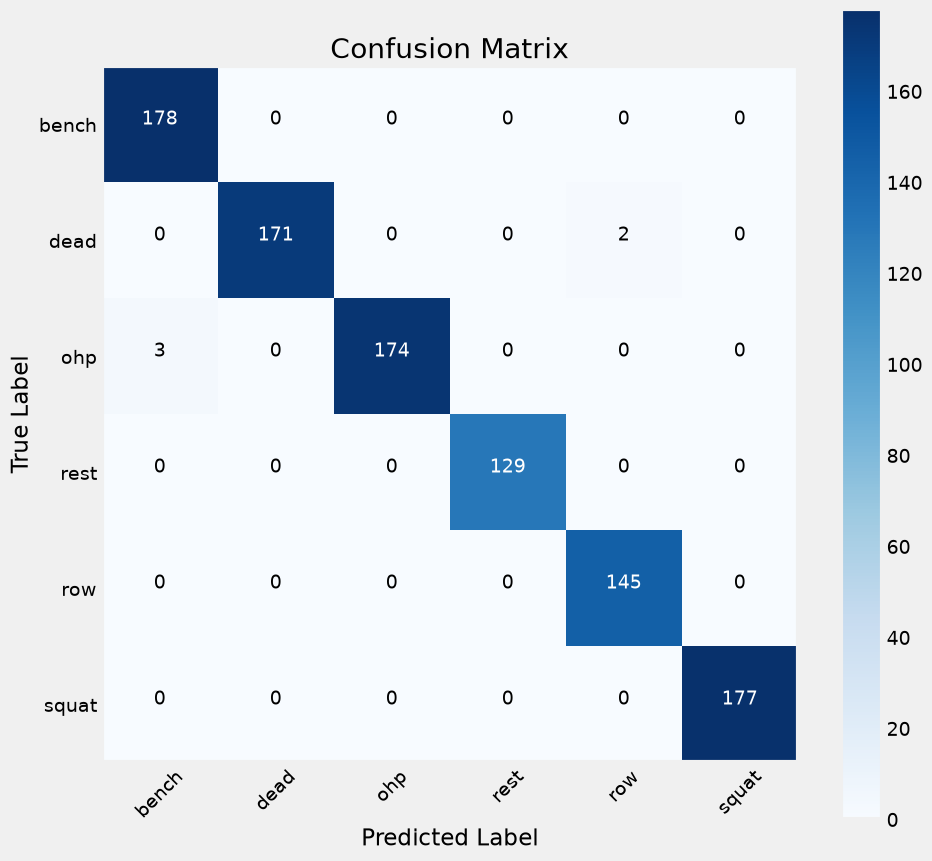

In [144]:
classes = model_lgbm.classes_
cm = confusion_matrix(y_test, y_pred, labels=classes)

# Plot the confusion matrix with labels
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)   # 2D array to image
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

# Loop over all coordinates on the image: (0, 0) ~ (5, 5) and add numbers
thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j, i, format(cm[i, j]), 
        horizontalalignment='center',
        color='white' if cm[i, j] > thresh else 'black'
    )
plt.grid(False)
plt.show()

### Feature importances from Light GBM

We can see that the previous **selected features** obtained from forward feature selection using decision tree **are different** from the features obtained from this method.

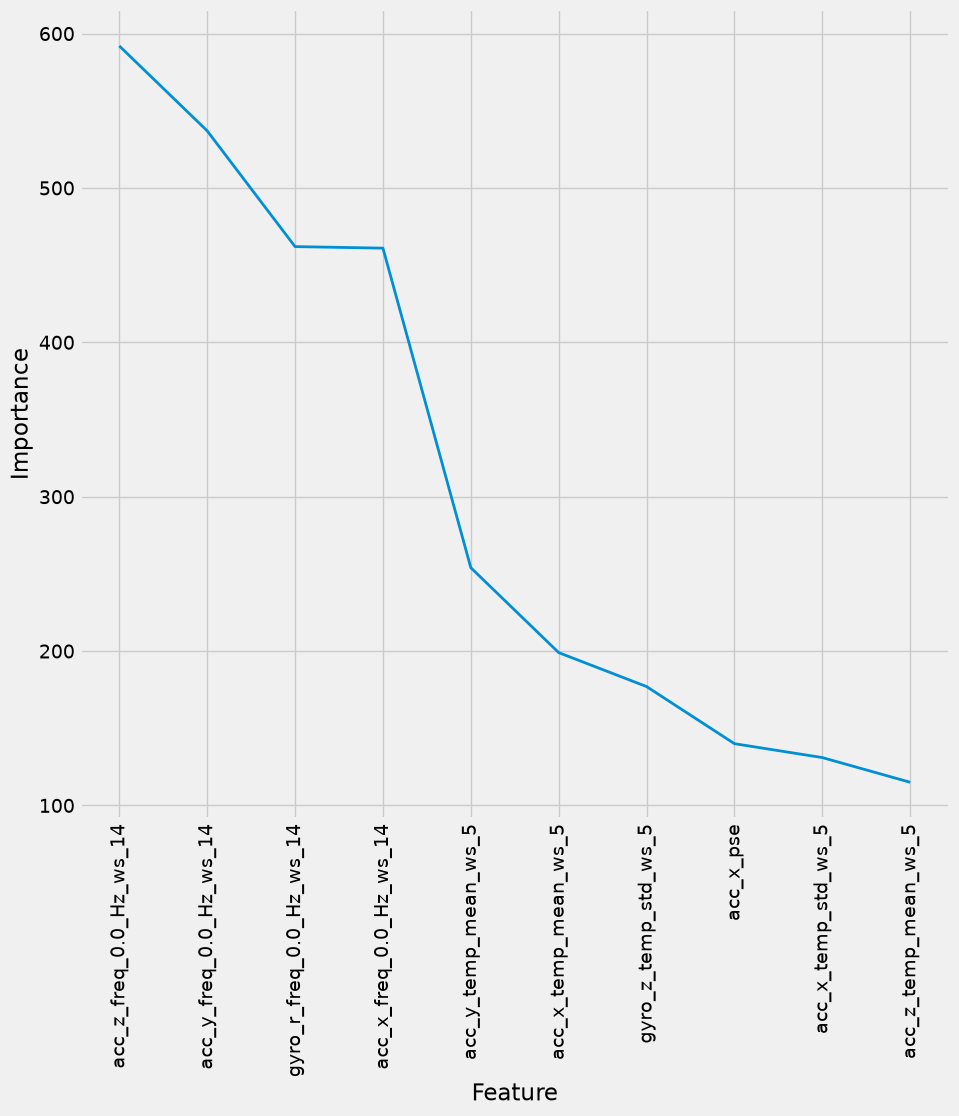

In [98]:
# Sort the importances in descending order with corresponding feature names
col_imp = sorted(
    list(zip(model_lgbm.feature_name_, model_lgbm.feature_importances_)),
    key=lambda x:x[1],
    reverse=True 
)
# Unzip and separate features and importances
col, imp = zip(*col_imp)

# Plot the top 10 features with high importance
plt.figure(figsize=(10, 10))
plt.plot(col[:10], imp[:10])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.show()

## 2. Train and test data based on participant

Imagine the situation where the model should predict the label for the new user. The sensor data is generally similar for the same exercies, but could have slight difference user by user. Even in this case, the model should be able to predict accurately. So, we will **leave out one participant (A) data for testing**.

In [165]:
df_participant = df.drop(['category', 'set', 'duration'], axis=1)

X_train = df_participant[df_participant['participant']!='A'].drop(['participant', 'label'], axis=1)
y_train = df_participant.loc[df_participant['participant']!='A', 'label']

X_test = df_participant[df_participant['participant']=='A'].drop(['participant', 'label'], axis=1)
y_test = df_participant.loc[df_participant['participant']=='A', 'label']

print('Train set size:', X_train.shape)
print('Test set size:', X_test.shape)

Train set size: (2606, 116)
Test set size: (1307, 116)


> NOTE: The ratio of train and test sets is about **2:1**, as the most of data we have is from the participant A.

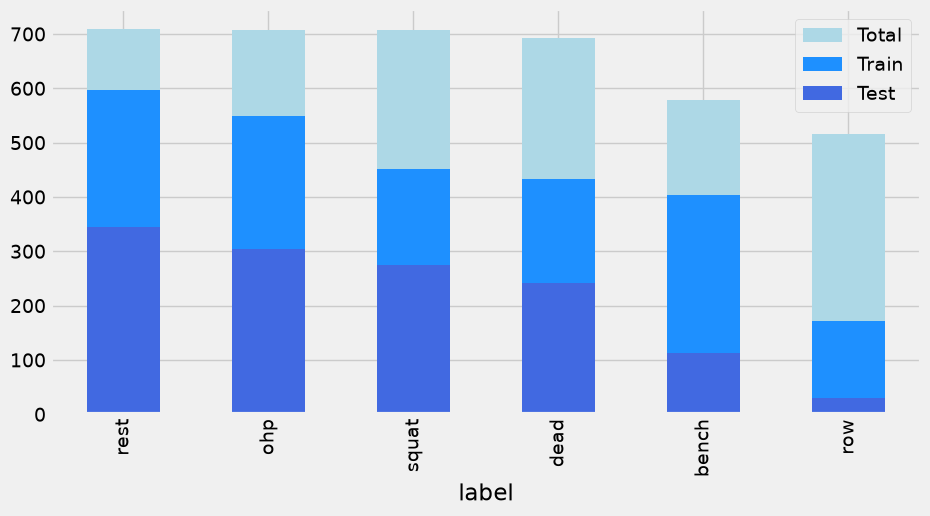

In [169]:
# Visualise the y values
fig, ax = plt.subplots(figsize=(10, 5))
df_participant['label'].value_counts().plot(kind='bar', color='lightblue', label='Total', ax=ax)
y_train.value_counts().plot(kind='bar', color='dodgerblue', label='Train', ax=ax)
y_test.value_counts().plot(kind='bar', color='royalblue', label='Test', ax=ax)
plt.legend()
plt.show()

> NOTE: Unlike previous train/test split, we didn't focus on the stratification of the classes, thus, the classes are **not stratified**. However, we at least have the Bench Press and Barbell Row data.

> NOTE: The process and the code below are the same as above.

## Foward feature selection using decision tree

Use `SequentialFeatureSelector` from scikit-learn where the estimator is decision tree. As the the number of data points for each class is not imbalanced, we will use `accuracy` for performance metric.

* Using all features

In [173]:
clf_df = DecisionTreeClassifier(
    max_depth=10, min_samples_leaf=50, random_state=42
)
sfs = SequentialFeatureSelector(
    estimator=clf_df,
    n_features_to_select=10,    # Select 10 features
    # n_features_to_select='auto',
    # tol=0.0005,     # Percentage increase
    direction='forward',
    scoring='accuracy',
    cv=5
)
sfs.fit(X_train, y_train)

,estimator estimator: estimator instanceAn unfitted estimator.,DecisionTreeC...ndom_state=42)
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",10
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.",'accuracy'
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](116,)","['acc_x','acc_y','acc_z',...,'gyro_r_freq_2.143_Hz_ws_14', 'gyro_r_freq_2.5_Hz_ws_14','acc_cluster']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,116
n_features_to_select_ n_features_to_select_: intThe number of features that were selected.,int64,np.int64(10)


In [174]:
# Selected 10 features
selected_features = sfs.get_feature_names_out()
selected_features

array(['acc_x', 'acc_y_temp_std_ws_5', 'gyro_z_temp_std_ws_5',
       'acc_r_temp_std_ws_5', 'gyro_r_temp_std_ws_5',
       'acc_y_freq_0.0_Hz_ws_14', 'acc_z_max_ampl_freq',
       'acc_r_max_ampl_freq', 'acc_r_freq_weighted',
       'gyro_r_freq_0.0_Hz_ws_14'], dtype=object)

## Grid search for best hyper-parameters

We will test all combinations of the feature sets and three models: **Random Forest, Light GBM and Neural Network**.

In [175]:
feature_sets = [
    feature_set_1,
    feature_set_2,
    feature_set_3,
    feature_set_4,
    selected_features
]

feature_names = [
    'Feature Set 1',
    'Feature Set 2',
    'Feature Set 3',
    'Feature Set 4',
    'Selected Features',
]

In [176]:
# Initialise a dataframe to collect each result from different feature sets.
score_df = pd.DataFrame()

for i, f in enumerate(feature_names):
    print(f'Feature set {i+1}: {f}===========================================')

    X_train_subset = X_train[feature_sets[i]]
    X_test_subset = X_test[feature_sets[i]]

    # 1. Grid search on Random Forest
    clf_rf = RandomForestClassifier(max_depth=10, random_state=42)
    params_rf = [
        {
            "min_samples_leaf": [5, 10, 50, 100, 200],
            "n_estimators": [10, 50, 100],
            "criterion": ["gini", "entropy"],
        }
    ]
    gs_rf = GridSearchCV(clf_rf, params_rf, scoring='accuracy')
    gs_rf.fit(X_train_subset, y_train)
    model_rf = gs_rf.best_estimator_
    y_pred = model_rf.predict(X_test_subset)
    score_rf = round(accuracy_score(y_test, y_pred), 4)

    print('Training done for Random Forest')
    
    #. 2. Grid search on LGBM
    clf_lgbm = LGBMClassifier(
        objective='multiclass', 
        max_depth=5,
        random_state=42,
        verbosity=-1)
    params_lgbm = [
        {
            "min_child_samples": [5, 10, 50, 100, 200],
            "n_estimators": [10, 50, 100]
        }
    ]

    # With statement to remove warning outputs
    gs_lgbm = GridSearchCV(clf_lgbm, params_lgbm, scoring='accuracy')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        gs_lgbm.fit(X_train_subset, y_train)
    model_lgbm = gs_lgbm.best_estimator_
    y_pred = model_lgbm.predict(X_test_subset)
    score_lgbm = round(accuracy_score(y_test, y_pred), 4)
    
    print('Training done for LightGBM')

    # 3. Grid search on Neural Network
    clf_nn = MLPClassifier(
        activation="logistic",
        learning_rate="adaptive",
        random_state=42
    )
    params_nn = [
        {
            "hidden_layer_sizes": [
                (5,), (10,), (25,), (100,),
                (100, 5,), (100, 10,),
            ],
            "max_iter": [100, 200, 500]
        }
    ]

    # With statement to remove warning outputs
    gs_nn = GridSearchCV(clf_nn, params_nn, scoring='accuracy')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        gs_nn.fit(X_train_subset, y_train)
    model_nn = gs_nn.best_estimator_
    y_pred = model_nn.predict(X_test_subset)
    score_nn = round(accuracy_score(y_test, y_pred), 4)

    print('Training done for Neural Network')

    # Save the performance result in dataframe
    new_scores = pd.DataFrame(
        {
            "model": ["RF", "LGBM", "NN"],
            "feature_set": f,
            "accuracy": [score_rf, score_lgbm, score_nn]
        }
    )
    score_df = pd.concat([score_df, new_scores], ignore_index=True)

Feature set 1: Feature Set 1===========================================
Training done for Random Forest
Training done for LightGBM
Training done for Neural Network
Feature set 2: Feature Set 2===========================================
Training done for Random Forest
Training done for LightGBM
Training done for Neural Network
Feature set 3: Feature Set 3===========================================
Training done for Random Forest
Training done for LightGBM
Training done for Neural Network
Feature set 4: Feature Set 4===========================================
Training done for Random Forest
Training done for LightGBM
Training done for Neural Network
Feature set 5: Selected Features===========================================
Training done for Random Forest
Training done for LightGBM
Training done for Neural Network


## Grouped bar chart to compare the results

Unlike above, there is no obvious trend of performance among the models. The feature set 3 and 4 generally worked well across the models. The best performance is slightly better than above, but the lowest is worse than above.

In [177]:
score_df.sort_values(by='accuracy', ascending=False, ignore_index=True)

,model,feature_set,accuracy
0,RF,Feature Set 4,0.9969
1,NN,Feature Set 4,0.9969
2,LGBM,Feature Set 4,0.9908
3,RF,Selected Features,0.9893
4,LGBM,Feature Set 3,0.9832
5,NN,Feature Set 3,0.9717
6,RF,Feature Set 3,0.9709
7,LGBM,Feature Set 1,0.9663
8,LGBM,Feature Set 2,0.9610
9,NN,Selected Features,0.9579


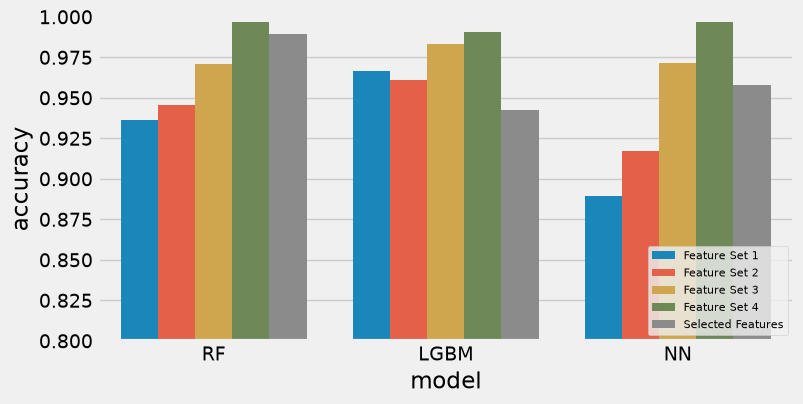

In [179]:
plt.figure(figsize=(8 ,4))
sns.barplot(data=score_df, x='model', y='accuracy', hue='feature_set')
plt.ylim(0.8, 1)
plt.legend(loc='lower right', fontsize=8)
plt.show()

## 1) Select simpler model and evaluate results

* **Best model**: **Random Forest** (used here), Neural Network
* **Selected features**: Feature set 4 (= all features)

In [232]:
# Re-train the model with the selected features
gs_rf = GridSearchCV(clf_rf, params_rf, scoring='accuracy')
gs_rf.fit(X_train[feature_set_4], y_train)
model_rf = gs_rf.best_estimator_
y_pred = model_rf.predict(X_test[feature_set_4])
score_rf = round(accuracy_score(y_test, y_pred), 4)

print('Best performance:', score_rf)

Best performance: 0.9969


### Confusion matrix

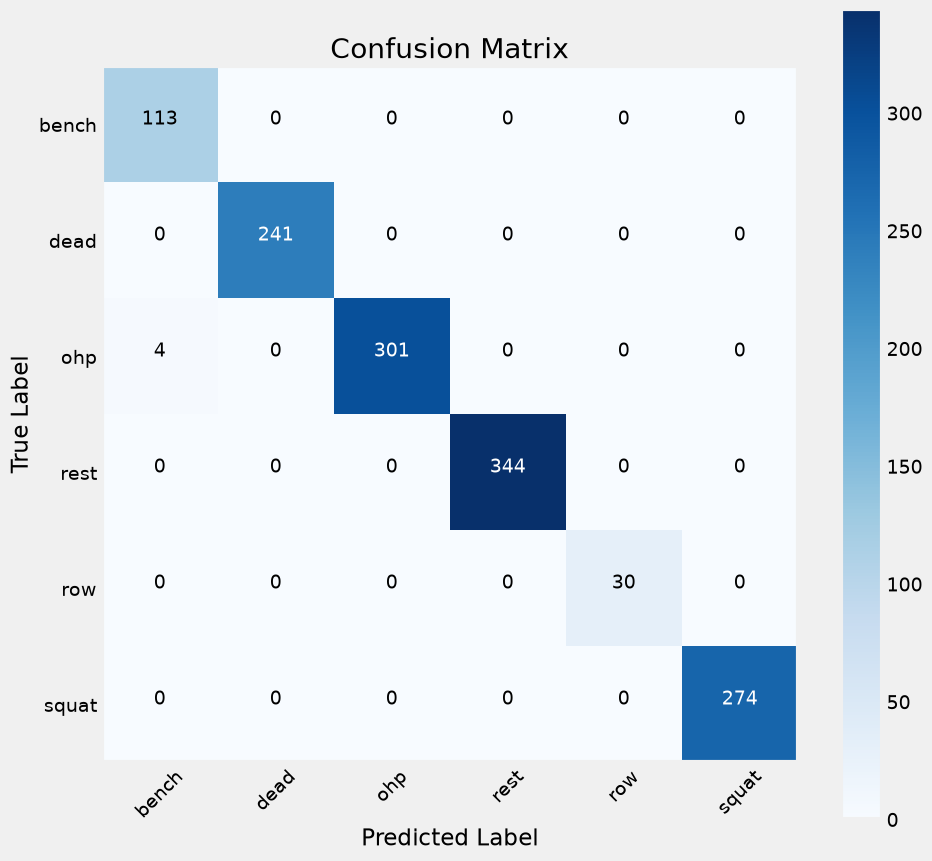

In [233]:
classes = model_rf.classes_
cm = confusion_matrix(y_test, y_pred, labels=classes)

# Plot the confusion matrix with labels
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)   # 2D array to image
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

# Loop over all coordinates on the image: (0, 0) ~ (5, 5) and add numbers
thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j, i, format(cm[i, j]), 
        horizontalalignment='center',
        color='white' if cm[i, j] > thresh else 'black'
    )
plt.grid(False)
plt.show()

### Feature importances from Random Forest

We can see that the previous **selected features** obtained from forward feature selection using decision tree **are different** from the features obtained from this method.

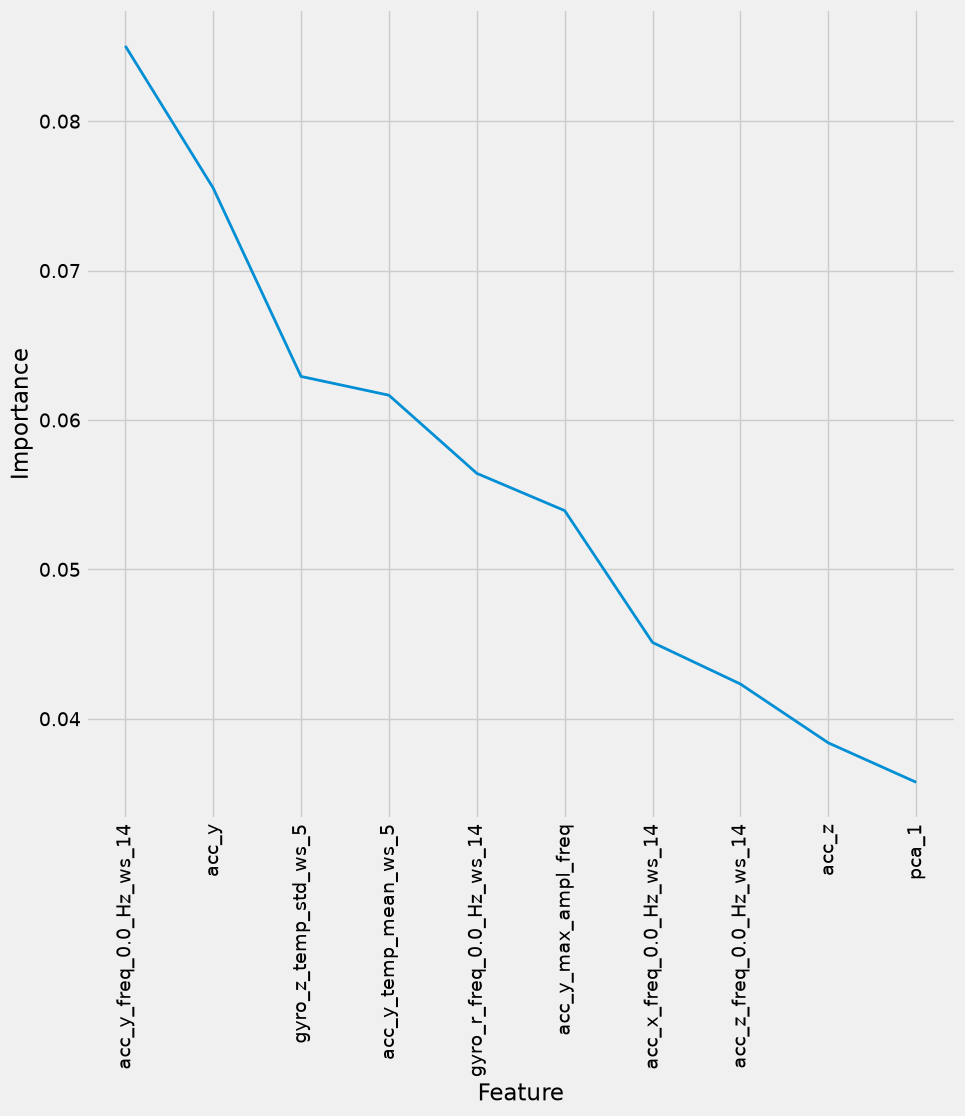

In [209]:
# Sort the importances in descending order with corresponding feature names
col_imp = sorted(
    list(zip(model_rf.feature_names_in_, model_rf.feature_importances_)),
    key=lambda x:x[1],
    reverse=True 
)
# Unzip and separate features and importances
col, imp = zip(*col_imp)

# Plot the top 10 features with high importance
plt.figure(figsize=(10, 10))
plt.plot(col[:10], imp[:10])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.show()

## 2) Select more complex model

* **Best Model**: Random Forest, **Neural Network** (used here)
* **Selected features**: Feature set 4 (= all features)

In [234]:
# Re-train the model with the selected features
gs_nn = GridSearchCV(clf_nn, params_nn, scoring='accuracy')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    gs_nn.fit(X_train[feature_set_4], y_train)
model_nn = gs_nn.best_estimator_
y_pred = model_nn.predict(X_test[feature_set_4])
score_nn = round(accuracy_score(y_test, y_pred), 4)

print('Best performance:', score_nn)

Best performance: 0.9969


### Confusion matrix

The confusion matrix shows the exactly same classification result as the one of Random Forest above. Both also showed the same accuracy.

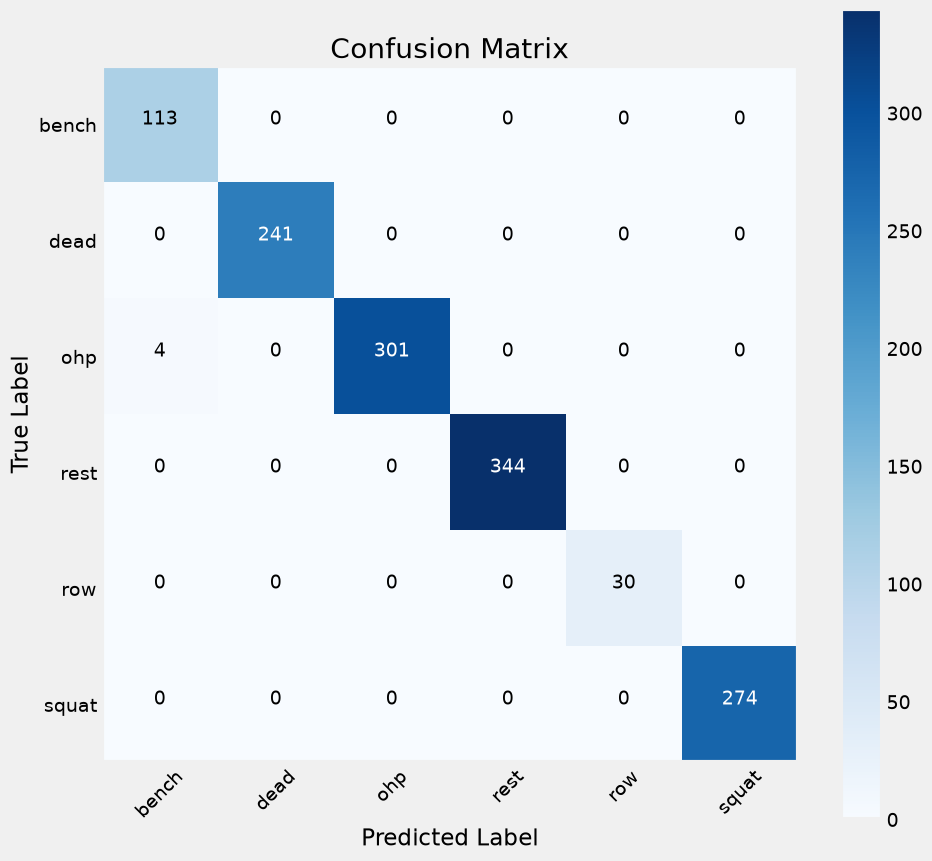

In [237]:
classes = model_nn.classes_
cm = confusion_matrix(y_test, y_pred, labels=classes)

# Plot the confusion matrix with labels
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)   # 2D array to image
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

# Loop over all coordinates on the image: (0, 0) ~ (5, 5) and add numbers
thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j, i, format(cm[i, j]), 
        horizontalalignment='center',
        color='white' if cm[i, j] > thresh else 'black'
    )
plt.grid(False)
plt.show()